### Load the required Python libraries.

In [73]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


### LOAD CSV

In [74]:
columns = [ 'id',
            'bfs_name',
            'bfs_number',
            'lat',
            'lon',
            'brand',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp']

df_supermarkets = pd.read_csv("supermarkets_data_enriched.csv")

df_supermarkets.head()


,Unnamed: 0,type,id,lat,lon,brand,shop,addr:city,addr:housenumber,addr:postcode,geometry,index_right,bfs_name,bfs_number,pop,pop_dens,frg_pct,emp
0,0,node,33126515,47.155616,9.037915,Spar,supermarket,NaN,NaN,NaN,POINT (9.0379152 47.1556157),227,Schänis,3315,3876,97.142857,13.054696,1408.0
1,1,node,280130028,47.155492,9.039666,ALDI,supermarket,Schänis,3,8718.0,POINT (9.0396663 47.1554921),227,Schänis,3315,3876,97.142857,13.054696,1408.0
2,2,node,6122906632,47.158959,9.044477,Denner,supermarket,Schänis,14,8718.0,POINT (9.0444769 47.1589589),227,Schänis,3315,3876,97.142857,13.054696,1408.0
3,3,node,9019298862,47.155185,9.038472,Lidl,supermarket,NaN,NaN,NaN,POINT (9.0384722 47.1551854),227,Schänis,3315,3876,97.142857,13.054696,1408.0
4,4,node,36726161,47.226191,8.980329,Migros,supermarket,Uznach,25,8730.0,POINT (8.9803292 47.2261912),1217,Uznach,3339,6489,860.610080,27.862537,3500.0


### DROP Null Values

In [75]:
columns = [ 'id',
            'bfs_name',
            'bfs_number',
            'lat',
            'lon',
            'brand',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp']
df_supermarkets = df_supermarkets.dropna(subset=columns)

df_supermarkets[columns].info()


<class 'pandas.core.frame.DataFrame'>
Index: 1979 entries, 0 to 3239
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1979 non-null   int64  
 1   bfs_name    1979 non-null   object 
 2   bfs_number  1979 non-null   int64  
 3   lat         1979 non-null   float64
 4   lon         1979 non-null   float64
 5   brand       1979 non-null   object 
 6   pop         1979 non-null   int64  
 7   pop_dens    1979 non-null   float64
 8   frg_pct     1979 non-null   float64
 9   emp         1979 non-null   float64
dtypes: float64(5), int64(3), object(2)
memory usage: 170.1+ KB


### Create a subset named ‘df_sub’

In [76]:
df_sub = df_supermarkets.loc[
    df_supermarkets['brand'].isin(['Migros', 'Volg'])
].copy()

df_sub['brand'].value_counts()


brand
Migros    486
Volg      210
Name: count, dtype: int64

### Create train/test samples

In [77]:
# Features
X = df_sub[['lat', 'lon', 'pop', 'pop_dens', 'frg_pct', 'emp']]

# Target
y = df_sub['brand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # or 0.3, 0.5 – up to you
    random_state=42,
    stratify=y           # keep Migros/Volg ratio similar in train/test
)

X_train.shape, X_test.shape


((556, 6), (140, 6))

### Fit the classification tree model

In [78]:
clf_tree = DecisionTreeClassifier(
    max_depth=4,     # you can play with this
    random_state=42
)

clf_tree.fit(X_train, y_train)

y_pred_tree = clf_tree.predict(X_test)


### Text representation of the tree

In [79]:
feature_names = X.columns.tolist()
tree_text = export_text(clf_tree, feature_names=feature_names)
print(tree_text)


|--- pop <= 3661.00
|   |--- lat <= 46.79
|   |   |--- pop_dens <= 38.28
|   |   |   |--- frg_pct <= 18.23
|   |   |   |   |--- class: Volg
|   |   |   |--- frg_pct >  18.23
|   |   |   |   |--- class: Volg
|   |   |--- pop_dens >  38.28
|   |   |   |--- emp <= 241.50
|   |   |   |   |--- class: Volg
|   |   |   |--- emp >  241.50
|   |   |   |   |--- class: Migros
|   |--- lat >  46.79
|   |   |--- emp <= 1558.50
|   |   |   |--- frg_pct <= 19.37
|   |   |   |   |--- class: Volg
|   |   |   |--- frg_pct >  19.37
|   |   |   |   |--- class: Volg
|   |   |--- emp >  1558.50
|   |   |   |--- frg_pct <= 18.68
|   |   |   |   |--- class: Migros
|   |   |   |--- frg_pct >  18.68
|   |   |   |   |--- class: Volg
|--- pop >  3661.00
|   |--- pop_dens <= 28.81
|   |   |--- class: Volg
|   |--- pop_dens >  28.81
|   |   |--- emp <= 11027.00
|   |   |   |--- pop <= 19939.00
|   |   |   |   |--- class: Migros
|   |   |   |--- pop >  19939.00
|   |   |   |   |--- class: Volg
|   |   |--- emp >  11

### Visualize the tree

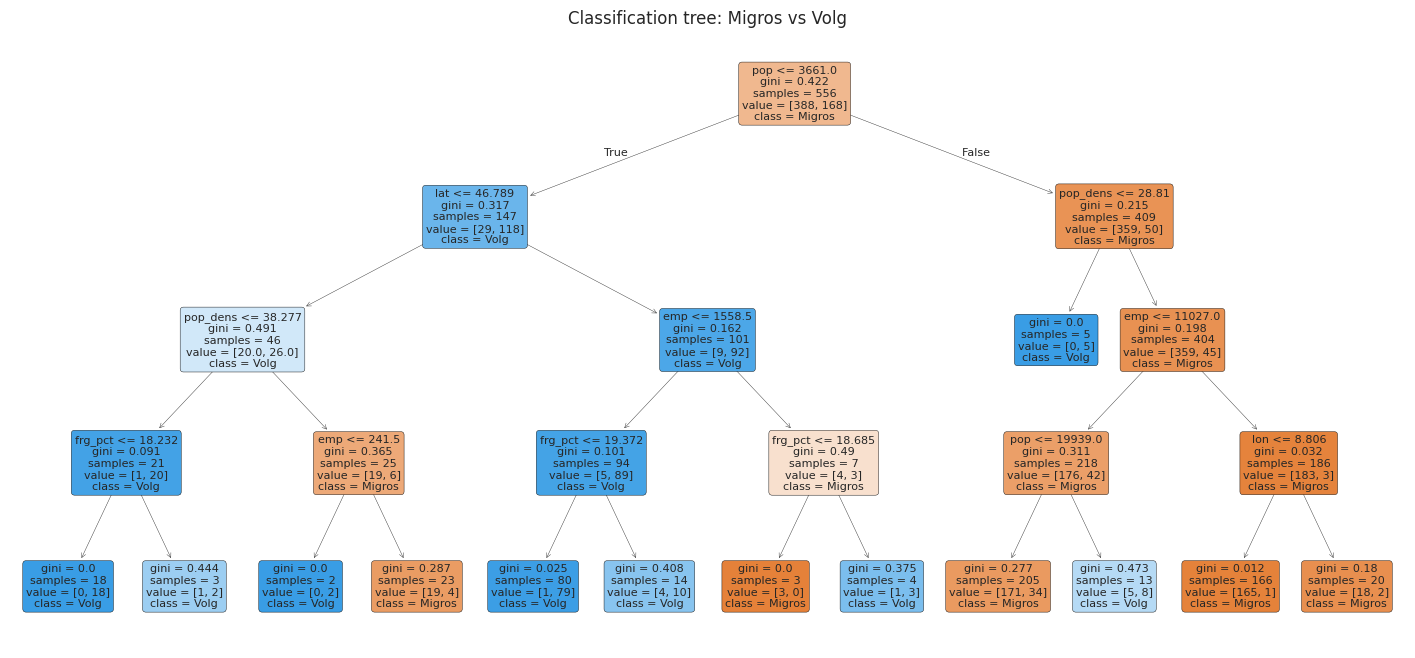

In [80]:
plt.figure(figsize=(18, 8))
plot_tree(
    clf_tree,
    feature_names=feature_names,
    class_names=clf_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Classification tree: Migros vs Volg")
plt.show()


### Confusion matrix & classification report

In [81]:
cm = confusion_matrix(y_test, y_pred_tree, labels=clf_tree.classes_)

print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(y_test, y_pred_tree))


Confusion matrix:
[[90  8]
 [16 26]]

Classification report:
              precision    recall  f1-score   support

      Migros       0.85      0.92      0.88        98
        Volg       0.76      0.62      0.68        42

    accuracy                           0.83       140
   macro avg       0.81      0.77      0.78       140
weighted avg       0.82      0.83      0.82       140



### Print the ROC curve and AUC of the model.

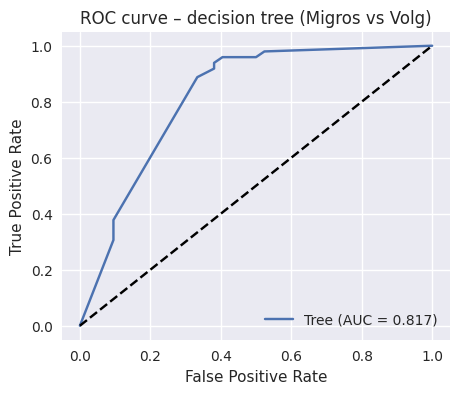

AUC (decision tree): 0.817


In [82]:
# Choose positive class name
positive_class = "Migros"

# Probabilities for the positive class
proba_test = clf_tree.predict_proba(X_test)
pos_idx = list(clf_tree.classes_).index(positive_class)
y_score = proba_test[:, pos_idx]

# Binarize y_test (1 = Migros, 0 = other)
y_test_bin = (y_test == positive_class).astype(int)

fpr, tpr, thresholds = roc_curve(y_test_bin, y_score)
auc_value = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Tree (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – decision tree (Migros vs Volg)")
plt.legend()
plt.show()

print(f"AUC (decision tree): {auc_value:.3f}")


### create a random forest classifier

In [83]:
X2 = df_sub[['lat', 'lon', 'pop', 'pop_dens', 'frg_pct', 'emp']]
y2 = df_sub['brand']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)


### Fit random forest & predict

In [84]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_clf.fit(X2_train, y2_train)
y2_pred = rf_clf.predict(X2_test)


### Confusion matrix & classification report (RF)

In [85]:
cm_rf = confusion_matrix(y2_test, y2_pred, labels=rf_clf.classes_)

print("Confusion matrix (Random Forest):")
print(cm_rf)
print()
print("Classification report (Random Forest):")
print(classification_report(y2_test, y2_pred))


Confusion matrix (Random Forest):
[[89  9]
 [14 28]]

Classification report (Random Forest):
              precision    recall  f1-score   support

      Migros       0.86      0.91      0.89        98
        Volg       0.76      0.67      0.71        42

    accuracy                           0.84       140
   macro avg       0.81      0.79      0.80       140
weighted avg       0.83      0.84      0.83       140



### Show the feature importance in a bar chart.

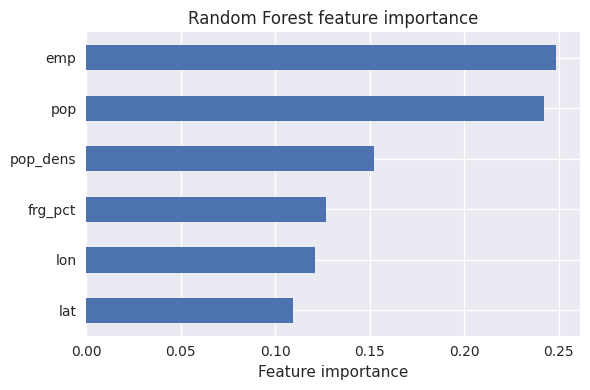

emp         0.248769
pop         0.242090
pop_dens    0.152495
frg_pct     0.126625
lon         0.120835
lat         0.109186
dtype: float64

In [86]:
importances = rf_clf.feature_importances_
feat_names = X2_train.columns

imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(6, 4))
imp_series.plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

imp_series.sort_values(ascending=False)


### Print the ROC curve and AUC of the model.

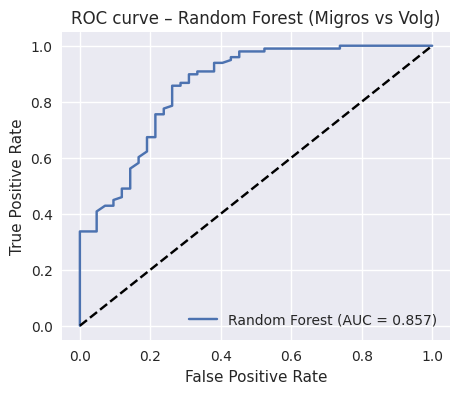

AUC (Random Forest): 0.857


In [87]:
positive_class = "Migros"

proba_test_rf = rf_clf.predict_proba(X2_test)
pos_idx_rf = list(rf_clf.classes_).index(positive_class)
y2_score = proba_test_rf[:, pos_idx_rf]

y2_test_bin = (y2_test == positive_class).astype(int)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y2_test_bin, y2_score)
auc_rf = roc_auc_score(y2_test_bin, y2_score)

plt.figure(figsize=(5, 4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – Random Forest (Migros vs Volg)")
plt.legend()
plt.show()

print(f"AUC (Random Forest): {auc_rf:.3f}")


### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [88]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-11-29 17:10:03
Python Version: 3.11.13
-----------------------------------
